In [45]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

def leastSquares(x,y):
    n = len(x)
    m = (n*(np.sum(x*y))-(np.sum(x)*np.sum(y)))/(n*np.sum(x**2)-(np.sum(x)**2))
    c = (np.sum(y)-m*(np.sum(x)))/n
    return m, c
    

Slope: 0.46065870891401733, Intercept: 3.115411123363745


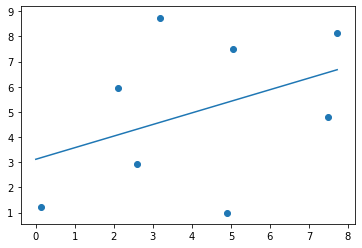

My Least Squares Function: 

Slope: 0.46065870891401733, Intercept: 3.115411123363745

Absolute error between my function and the numpy function:

m: 6.1e-16 c: 1.8e-15

Residuals:
[1.91262758 2.33774361 1.2163196  4.10376142 4.15062868 1.84272556
 1.37857957 1.44330632]


Max residual of 4.1506286772886885 at X = 4.9101005614760975

Min residual of 1.2163195958598196 at X = 2.606368465101603



In [60]:
#Parameters
elementLimit = 10
elementValueLimit = 10

# Data points
X = np.random.rand(np.ceil(rng.random()*elementLimit).astype(int))*elementValueLimit
X.sort()
Y = np.random.rand(len(X))*elementValueLimit

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")
x = np.linspace(0,np.max(X),len(Y))
plt.plot(x, m*x + c)
plt.scatter(X,Y)
plt.show()

print(f"My Least Squares Function: \n")
MYm, MYc = leastSquares(X, Y)
print(f"Slope: {m}, Intercept: {c}\n")

print(f"Absolute error between my function and the numpy function:\n")
print(f"m: {abs(MYm-m):.2} c: {abs(MYc-c):.2}\n")

# Residuals
residual = np.abs(Y - (m*x + c))
print("Residuals:")
print(residual)
print("\n")

maxResidual = np.max(residual)
maxResidIndex = X[np.argmax(residual)]
print(f"Max residual of {maxResidual} at X = {maxResidIndex}\n")

minResidual = np.min(residual)
minResidIndex = X[np.argmin(residual)]
print(f"Min residual of {minResidual} at X = {minResidIndex}\n")

Slope: 5.065194470227685, Intercept: 0.9571741915173259


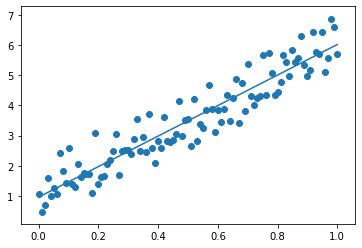

My Least Squares Function: 

Slope: 5.065194470227685, Intercept: 0.9571741915173259

Absolute error between my function and the numpy function:

m: 4.4e-15 c: 4.2e-15

Residuals:
[0.1135521  0.5332566  0.36784155 0.48231445 0.16332411 0.04970112
 0.2183999  1.09658933 0.44681457 0.00954613 1.13948601 0.12271964
 0.26488219 0.45080648 0.0402606  0.04365843 0.04984494 0.09634741
 0.77678649 1.1540434  0.5899717  0.38833268 0.40423825 0.05935907
 0.03164093 0.27582239 0.76278349 0.62593552 0.12124611 0.10235656
 0.0582896  0.14442876 0.30285947 0.90673308 0.18662009 0.23017958
 0.33851737 0.88838888 0.30934034 0.8496426  0.15410771 0.43059565
 0.52942079 0.30915729 0.39260484 0.39715237 0.24798275 0.81879675
 0.38804437 0.08127179 0.0460399  0.89200601 0.61826006 0.82093952
 0.29548588 0.48146828 0.04969986 0.84923409 0.00177539 0.81104658
 0.14407935 0.59050963 0.21391183 0.19192757 0.72242744 0.00782766
 0.56916073 0.92553001 0.34712541 0.62913517 0.85835561 0.23215689
 0.60237224 0.41

In [58]:
#Parameters
elementLimit = 10
elementValueLimit = 10
slopeLimit = 5
yInterceptLimit = 3

# Data points
X = np.arange(0,1.01,.01)
Y = rng.random()*slopeLimit*X+rng.random()*yInterceptLimit+(np.random.rand(len(X))-0.5)*2
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")
x = np.linspace(0,1,101)
plt.plot(x, m*x + c)
plt.scatter(X,Y)
plt.show()

print(f"My Least Squares Function: \n")
MYm, MYc = leastSquares(X, Y)
print(f"Slope: {m}, Intercept: {c}\n")

print(f"Absolute error between my function and the numpy function:\n")
print(f"m: {abs(MYm-m):.2} c: {abs(MYc-c):.2}\n")

# Residuals
residual = np.abs(Y - (m*x + c))
print("Residuals:")
print(residual)
print("\n")

maxResidual = np.max(residual)
maxResidIndex = np.argmax(residual)/100
print(f"Max residual of {maxResidual} at X = {maxResidIndex}\n")

minResidual = np.min(residual)
minResidIndex = np.argmin(residual)/100
print(f"Min residual of {minResidual} at X = {minResidIndex}\n")

In [ ]:
#My custom least squares method is VERY close to the numpy function--within 2 trillionths
#m and c value from numpy. This error is likely due to numpy being based in C which can be more
#accurate due to its low level memory manipulation.